In [50]:
# requirements
# !pip install qiskit[visualization]
# !pip install numpy


## Classical part of the problem


This code takes the full adjacency matrix, which gives the time cost between points assuming you can actually do them (it is not very specific, not dependent on the conditions)

The places themselves are defined by difficulty up to four levels:
- Urban
- Trail
- Mountain
- Snow

And the time of the year influences the state of the places.


As the user will give an initial point from which to begin a circular route, the first classical reduction we can do is to consider what is the effective explorable areas given a maximum difficulty level for the user. These constraints could be implemented as penalties in the QUBO formulation hamiltonian, but they are very effectively removed by classical preprocessing (the preprocessing is linear in the number of edges).



The adjacency matrix is written here

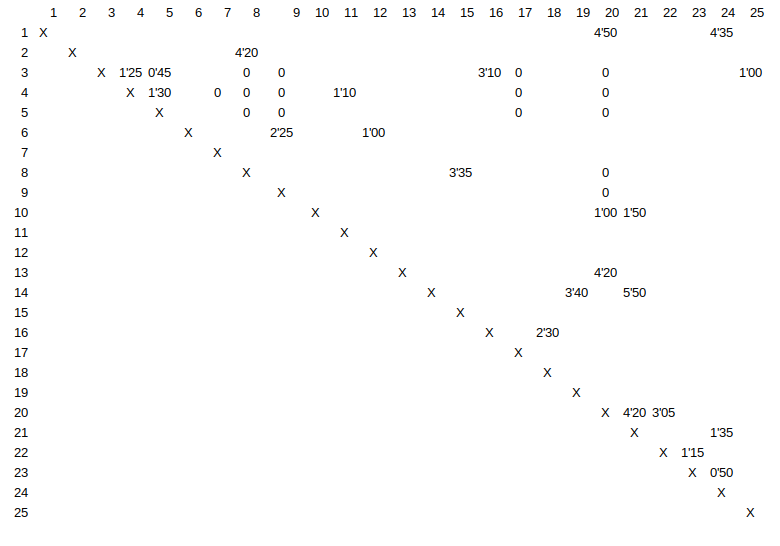

In [1]:
import numpy as np

# increase width for numpy prints
large_width = 400
np.set_printoptions(linewidth=large_width)


import pandas as pd

Nplaces = 25
benasque_data = pd.read_excel("Hackathon - data.xlsx")[:Nplaces]
# some are nan otherwise

place_to_index = {place: idx+1 for idx, place in enumerate(benasque_data["Place"])}
index_to_place = {idx+1: place for idx, place in enumerate(benasque_data["Place"])}


# Adjacency notation:
# adjacency[i] = {neighbour1:  cost1, neighbour2: cost2, ...]
# costs in minutes
adjacency_dict_given = {
				  1: {20: 4*60+50, 24: 4*60+35}, 
				  2: {8: 4*60+20}, 
				  3: {4: 1*60+25, 5: 45, 8: 0, 9: 0, 16: 3*60+10, 17: 0, 20: 0, 25: 1*60},
				  4: {5: 1*60+30, 7: 0, 8: 0, 9: 0, 11: 1*60+10, 17:0, 20: 0},
				  5: {8: 0, 9: 0, 17:0, 20: 0},
				  6: {9: 2*60+25, 12: 1*60},
				  7: {},
				  8: {15: 3*60+35, 20: 0},
				  9: {20: 0},
				  10: {20: 1*60, 21: 1*60+50},
				  11: {},
				  12: {},
				  13: {20: 4*60+20},
				  14: {19: 3*60+40, 21: 5*60+50},
				  15: {},
				  16: {18: 2*60+30},
				  17: {},
				  18: {},
				  19: {},
				  20: {21: 4*60+20, 22: 3*60+5},
				  21: {24: 1*60+35},
				  22: {23: 1*60+15},
				  23: {24: 50},
				  24: {},
				  25: {}}

## Add opposite paths (if i -> j,  j -> i)
adjacency_dict = {i: {} for i in adjacency_dict_given}

for place_i in adjacency_dict_given:
	for place_j in adjacency_dict_given[place_i]:
		adjacency_dict[place_i][place_j] = adjacency_dict_given[place_i][place_j]
		adjacency_dict[place_j][place_i] = adjacency_dict_given[place_i][place_j]



print(place_to_index)

{'Pico Aneto': 1, 'Tuca Alba': 2, 'Benasque': 3, 'Cerler': 4, 'Ancils': 5, 'Portillón de Benás': 6, 'Ski resort': 7, 'Baños de Benasque': 8, 'Hospital de Benasque': 9, "Forau d'aiguallut": 10, 'Tres Cascadas': 11, 'Salvaguardia': 12, 'Tuca Maladeta': 13, 'Cap Llauset': 14, 'Ibón Cregüeña': 15, 'Batisielles': 16, 'Eriste': 17, 'Ibón Eriste': 18, 'Tempestades': 19, 'La Besurta': 20, 'La Renclusa': 21, 'Escaleta': 22, 'Mulleres': 23, 'Salterillo': 24, 'Tres Barrancos': 25}


In [2]:
# define adjacency matrix and edge list

############
# We build adjacency matrix representation, with -1 to indicate non connected
############
def generate_adjacency_matrix(adjacency_dict):
    Nplaces = len(adjacency_dict)
    adjacency_matrix = np.zeros((Nplaces,Nplaces), dtype=np.float32)

    for i in range(Nplaces):
        for j in range(i, Nplaces):
            adjacency_matrix[i,j] = adjacency_dict[i+1].get(j+1,-1)
            adjacency_matrix[j,i] = adjacency_dict[i+1].get(j+1,-1)

    return adjacency_matrix



############
##### WE BUILD EDGE LIST
############


def generate_edge_list(adjacency_dict_given):
    # [(i, j, weight), ...]
    edge_list = []

    for place_i in adjacency_dict_given:
        for place_j in adjacency_dict_given[place_i]:
            edge_list.append((place_i, place_j, adjacency_dict_given[place_i][place_j]))

    return edge_list


def adjacency_dict_from_edge_list(edge_list):
    res_adjacency_dict = {i: {} for i in set([i for i, j, w in edge_list])} # + [j for i, j, w in edge_list])}  we don't need to check j due to symmetry
    for i, j, w in edge_list:
        res_adjacency_dict[i][j] = w
    return res_adjacency_dict





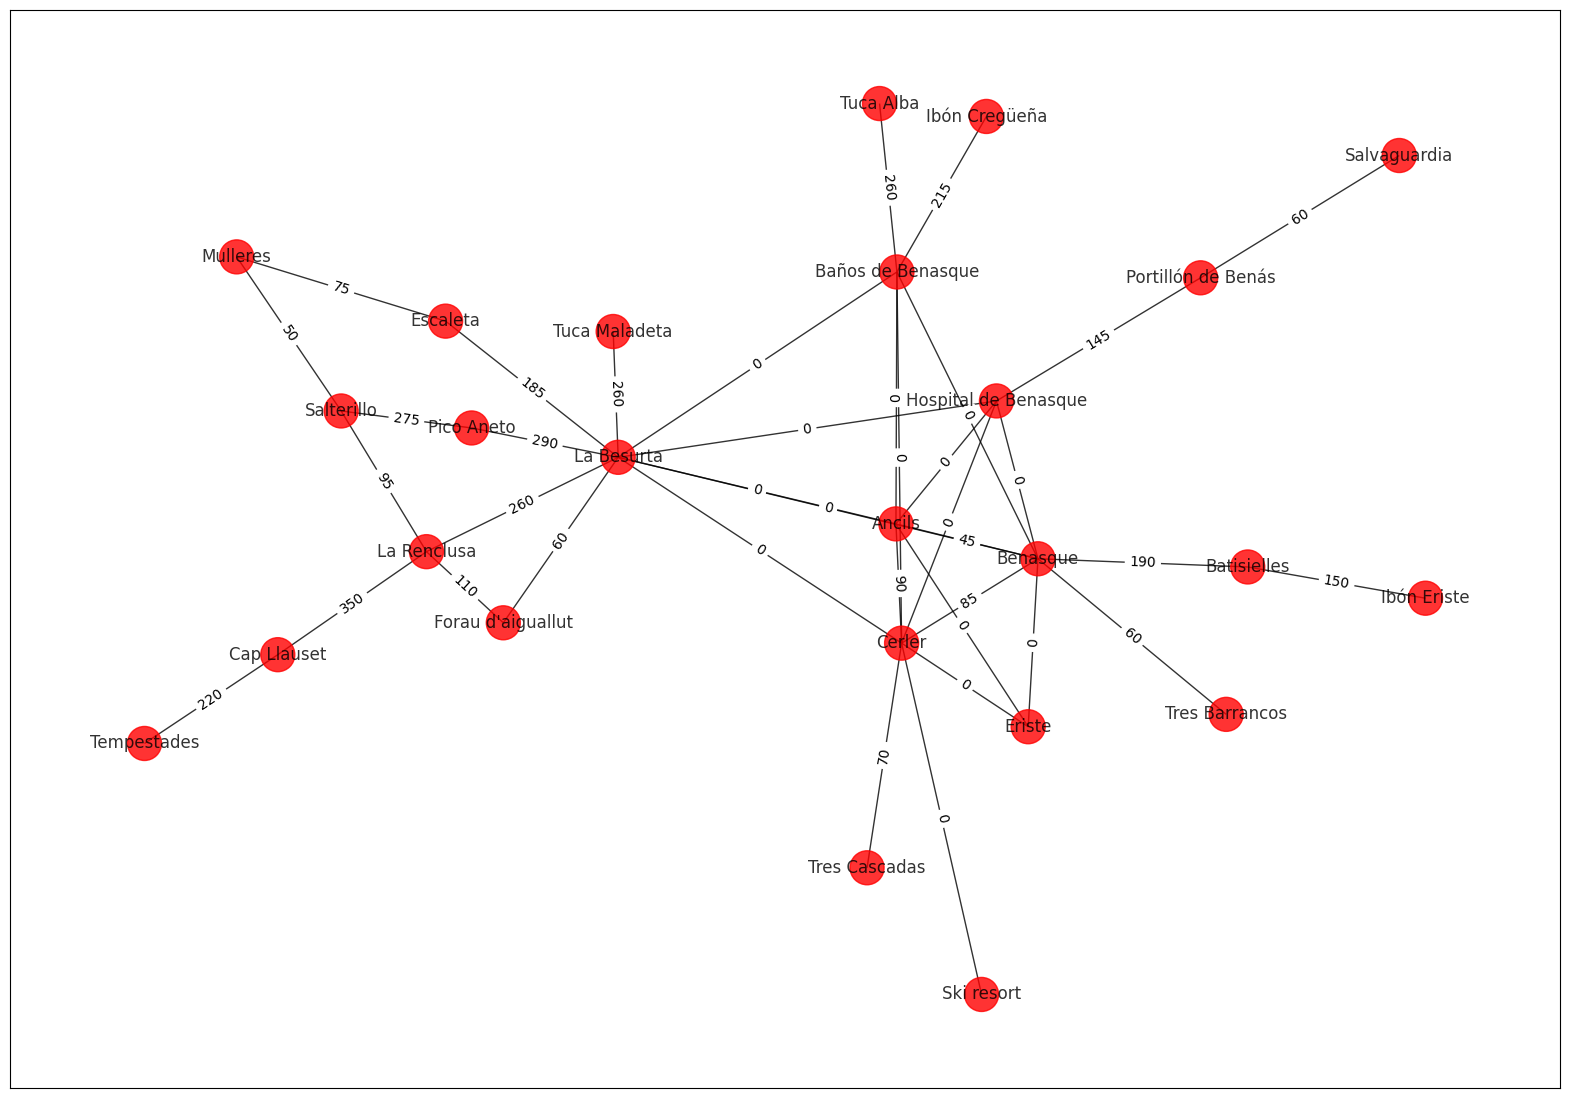

In [3]:
# Graph using networkx
import networkx as nx
import matplotlib.pyplot as plt

def draw_benasque_graph(adjacency_dict):
    bias = 60 # bias to account for 0 distance

    edge_list = generate_edge_list(adjacency_dict)

    G = nx.Graph()
    for u, v, weight in edge_list:
        G.add_edge(u, v, weight=weight+bias)

    G = nx.relabel_nodes(G, index_to_place)

    pos = nx.spring_layout(G)
    colors = ["r" for node in G.nodes()]

    print()

    def draw_graph(G, colors, pos):
        plt.figure(figsize=(20, 14))
        default_axes = plt.axes(frameon=True)
        nx.draw_networkx(G, node_color=colors, node_size=600, alpha=0.8, ax=default_axes, pos=pos)
        edge_labels = {edge: weight-bias for edge, weight in nx.get_edge_attributes(G, "weight").items()}
        nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)

    draw_graph(G, colors, pos)


draw_benasque_graph(adjacency_dict)


## We add restrictions

We remove points which are in conditions we can't manage

In [4]:
def get_gear(place_index, time):
    if time == "Summer":
        return benasque_data.loc[benasque_data["Index"] == place_index, "Summer gear"].values[0]
    else:
        return benasque_data.loc[benasque_data["Index"] == place_index, "Winter gear"].values[0]
    

gear_tiers = {"Urban": 0, "Trail": 1, "Mountain": 2, "Snow": 3}
def gear_check(gear, max_gear):
    return gear_tiers[gear] <= gear_tiers[max_gear]


print((get_gear(1, "Summer"), "Urban"))
print(gear_check(get_gear(1, "Summer"), "Urban"))


def limited_conditions(adjacency_dict, max_gear = "Urban", time = "Summer"):
    # Filter out nodes that exceed the maximum difficulty
    edge_list = generate_edge_list(adjacency_dict)
    filtered_edge_list = [(i, j, w) for i, j, w in edge_list if 
                          (gear_check(get_gear(i, time), max_gear) and gear_check(get_gear(j, time), max_gear))]
    
    return adjacency_dict_from_edge_list(filtered_edge_list)


('Snow', 'Urban')
False


Summer ['Urban', 'Trail', 'Mountain', 'Snow']

Winter ['Urban', 'Trail', 'Mountain', 'Snow']

Summer ['Urban', 'Trail', 'Mountain', 'Snow']

Winter ['Urban', 'Trail', 'Mountain', 'Snow']

Summer ['Urban', 'Trail', 'Mountain', 'Snow']

Winter ['Urban', 'Trail', 'Mountain', 'Snow']

Summer ['Urban', 'Trail', 'Mountain', 'Snow']

Winter ['Urban', 'Trail', 'Mountain', 'Snow']



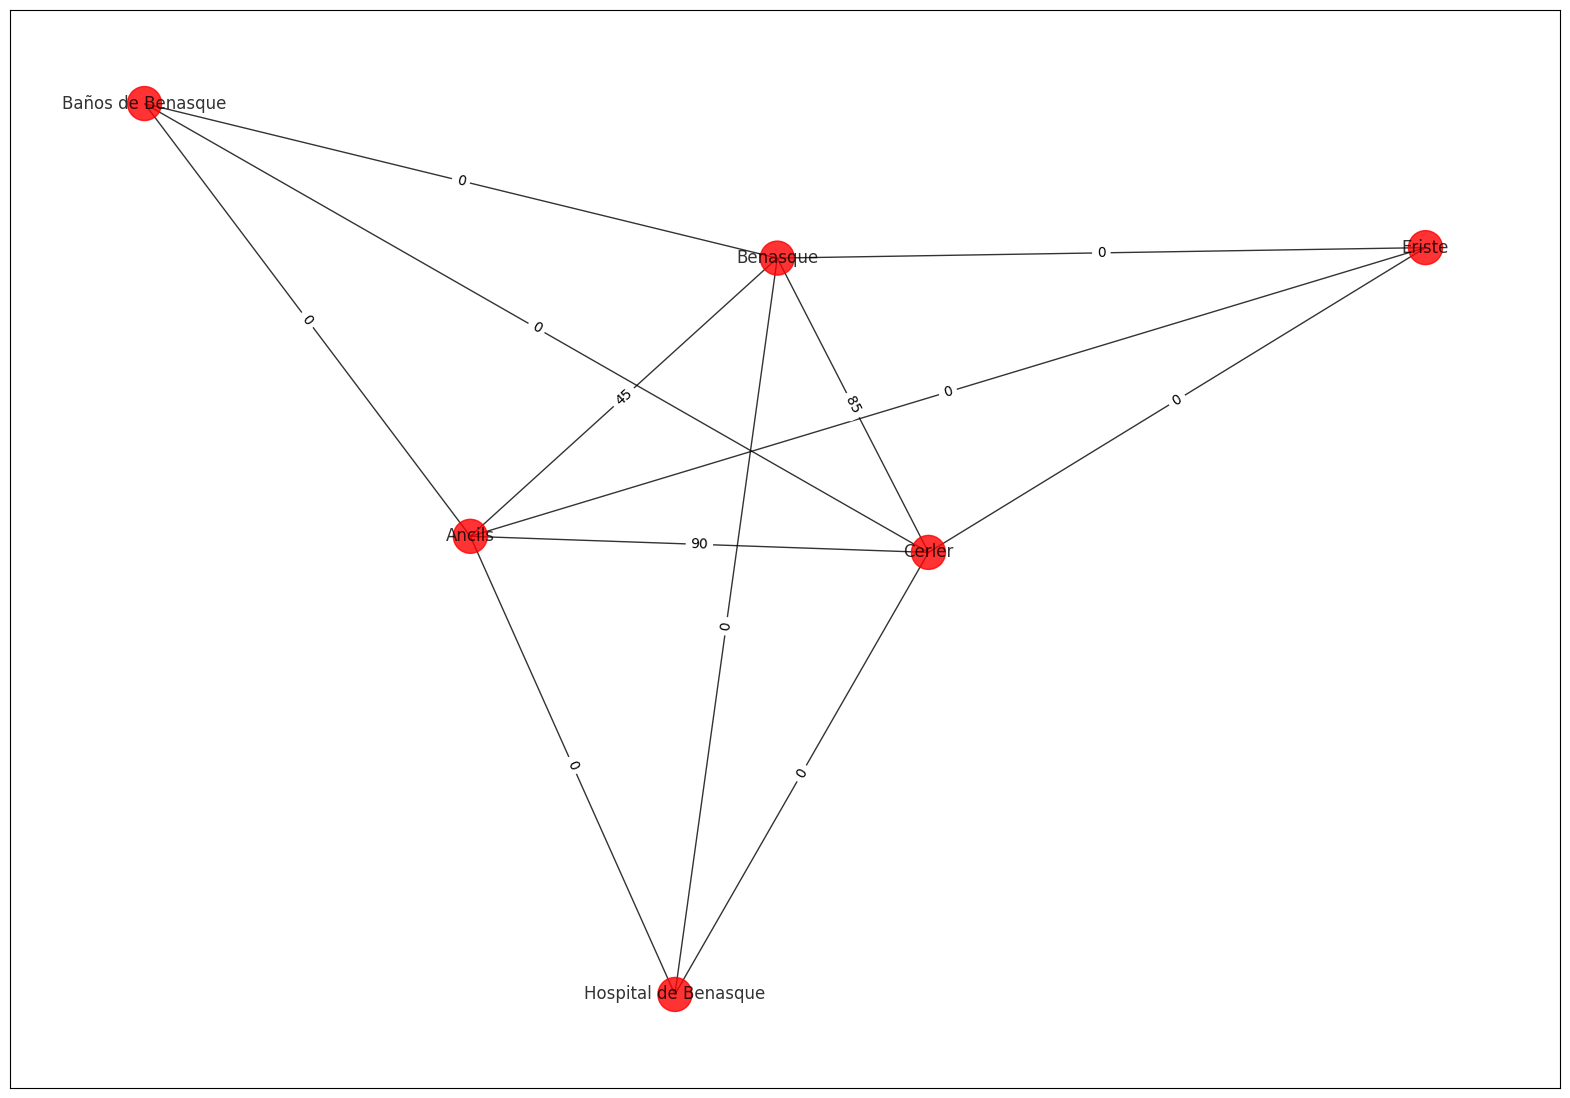

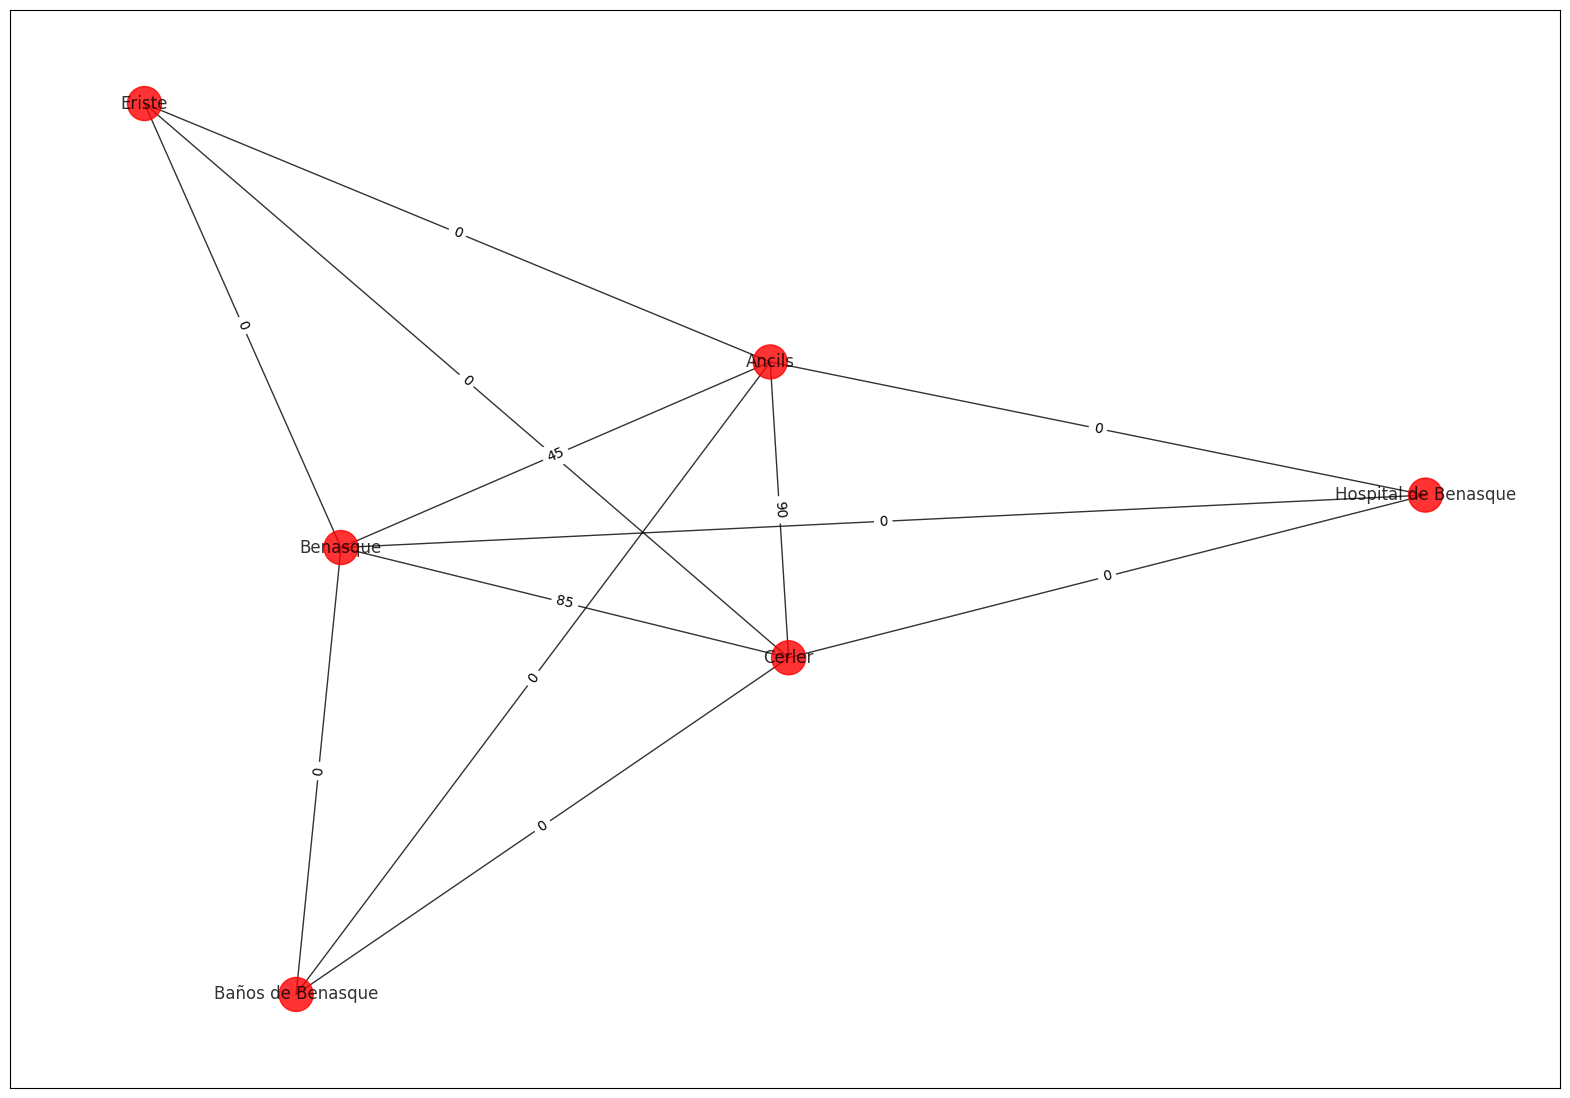

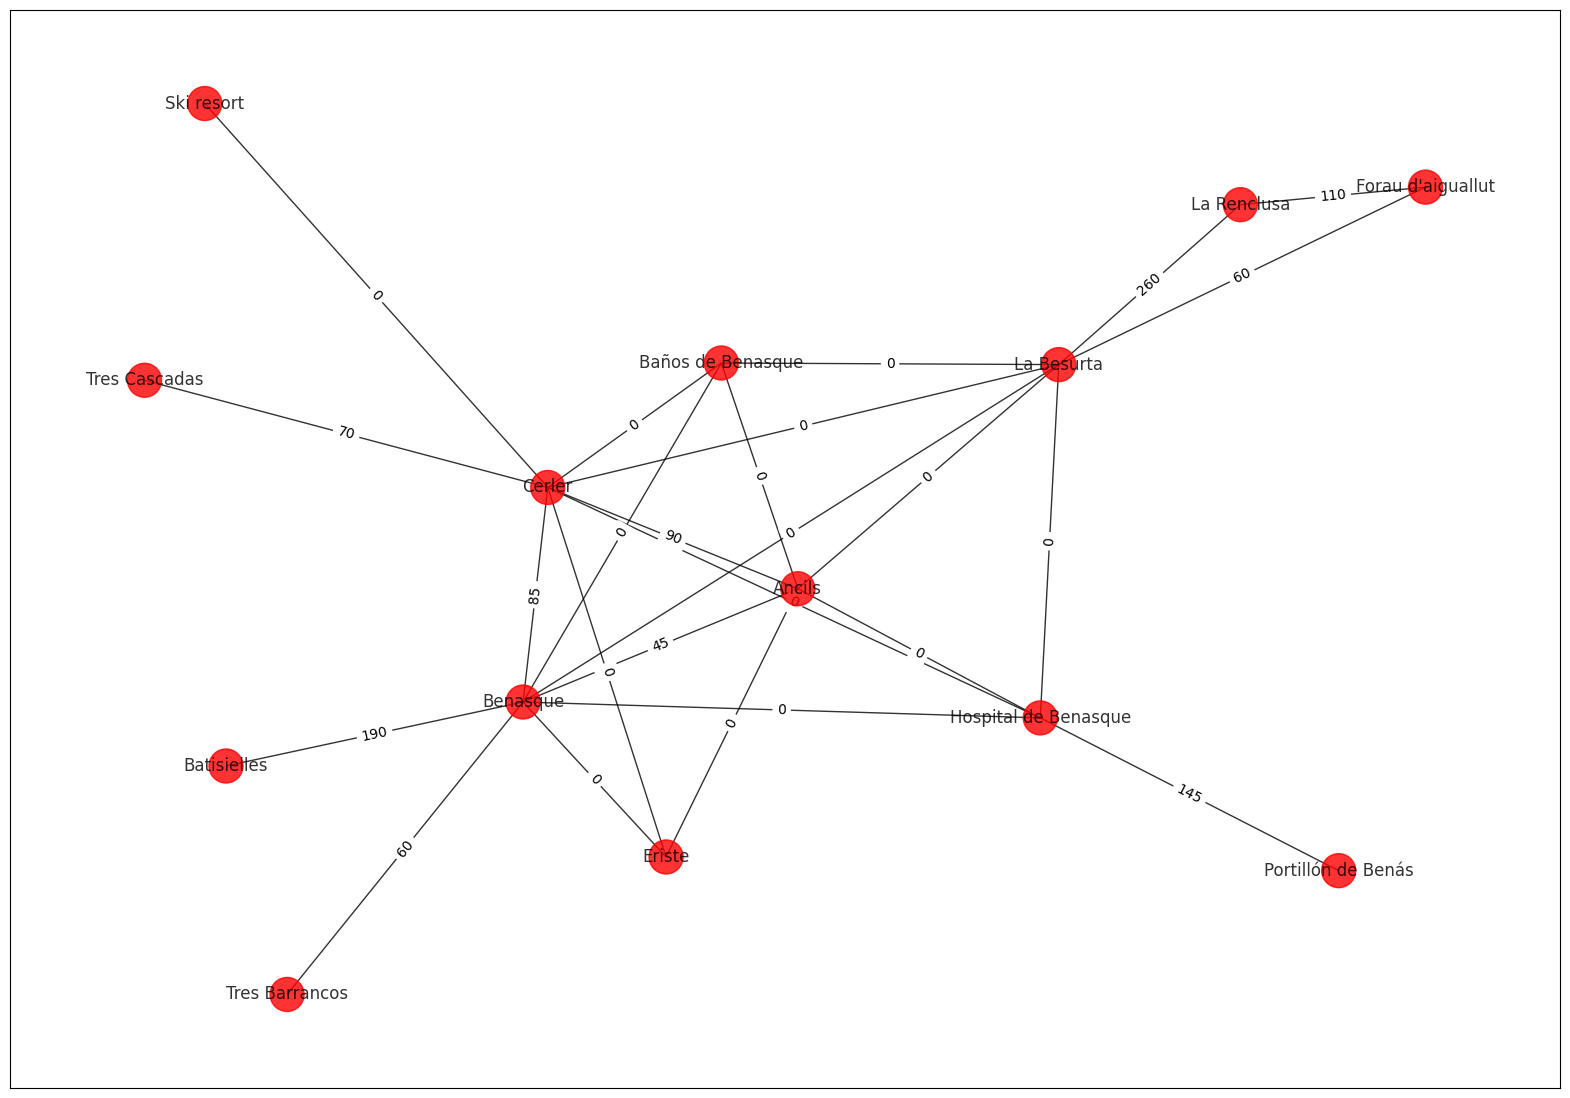

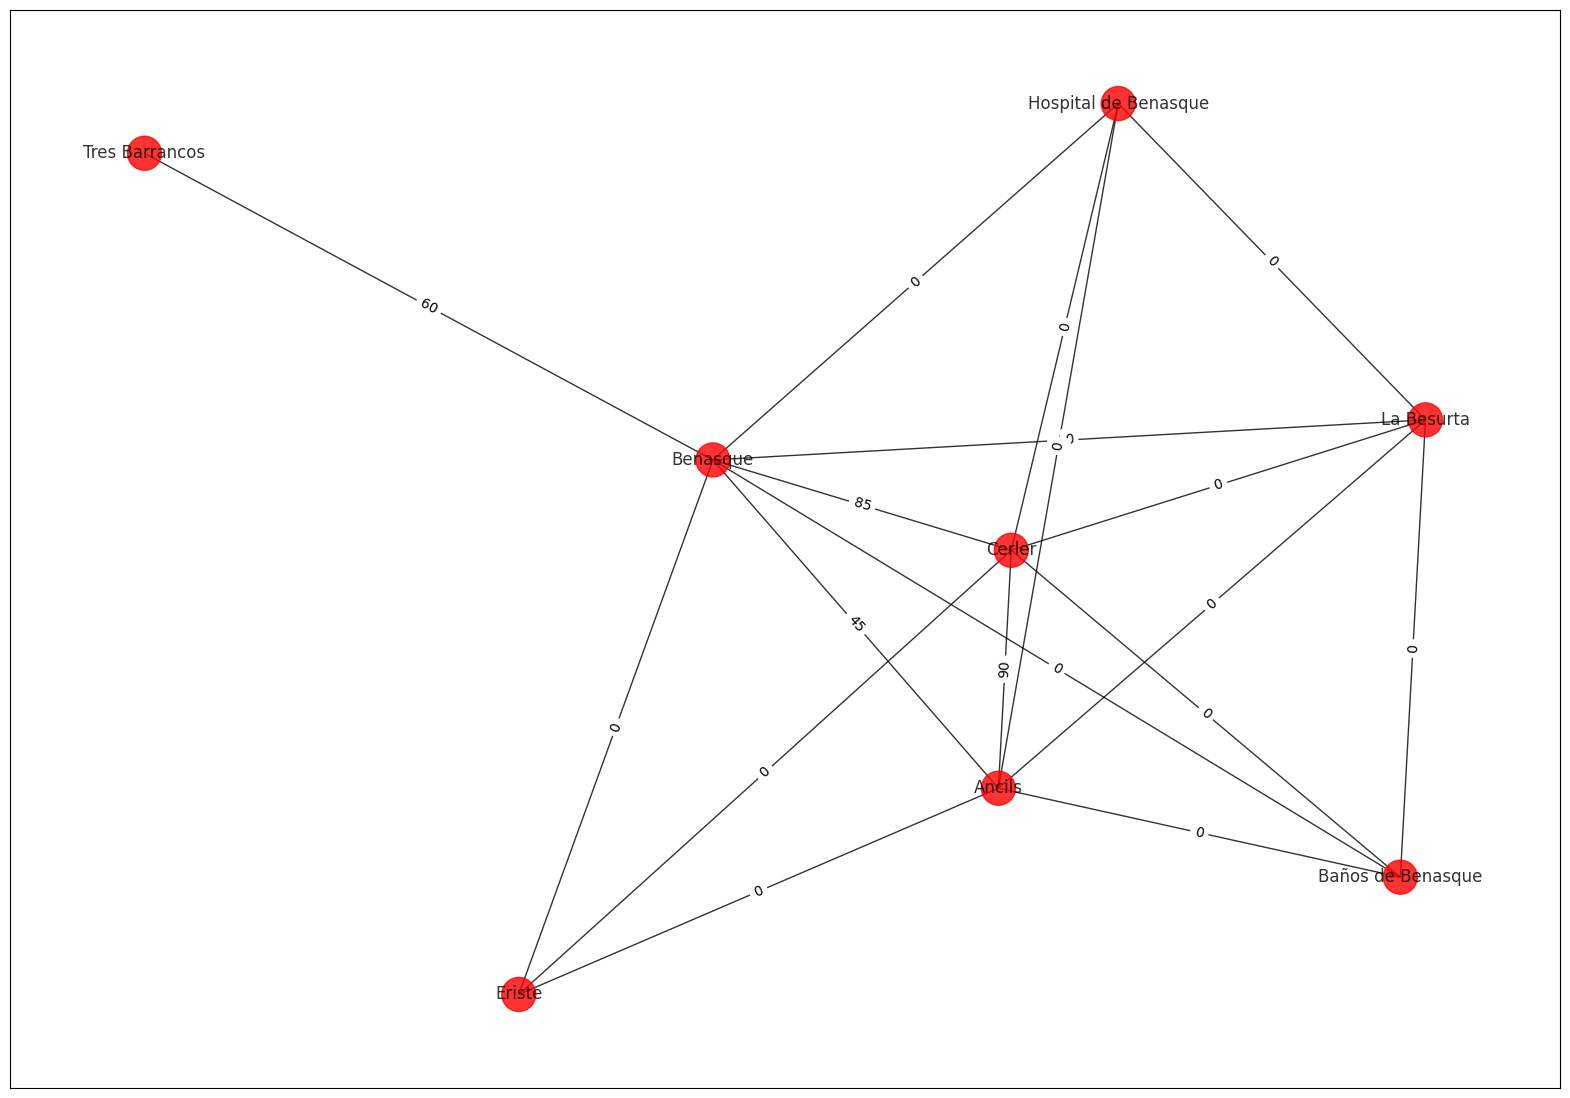

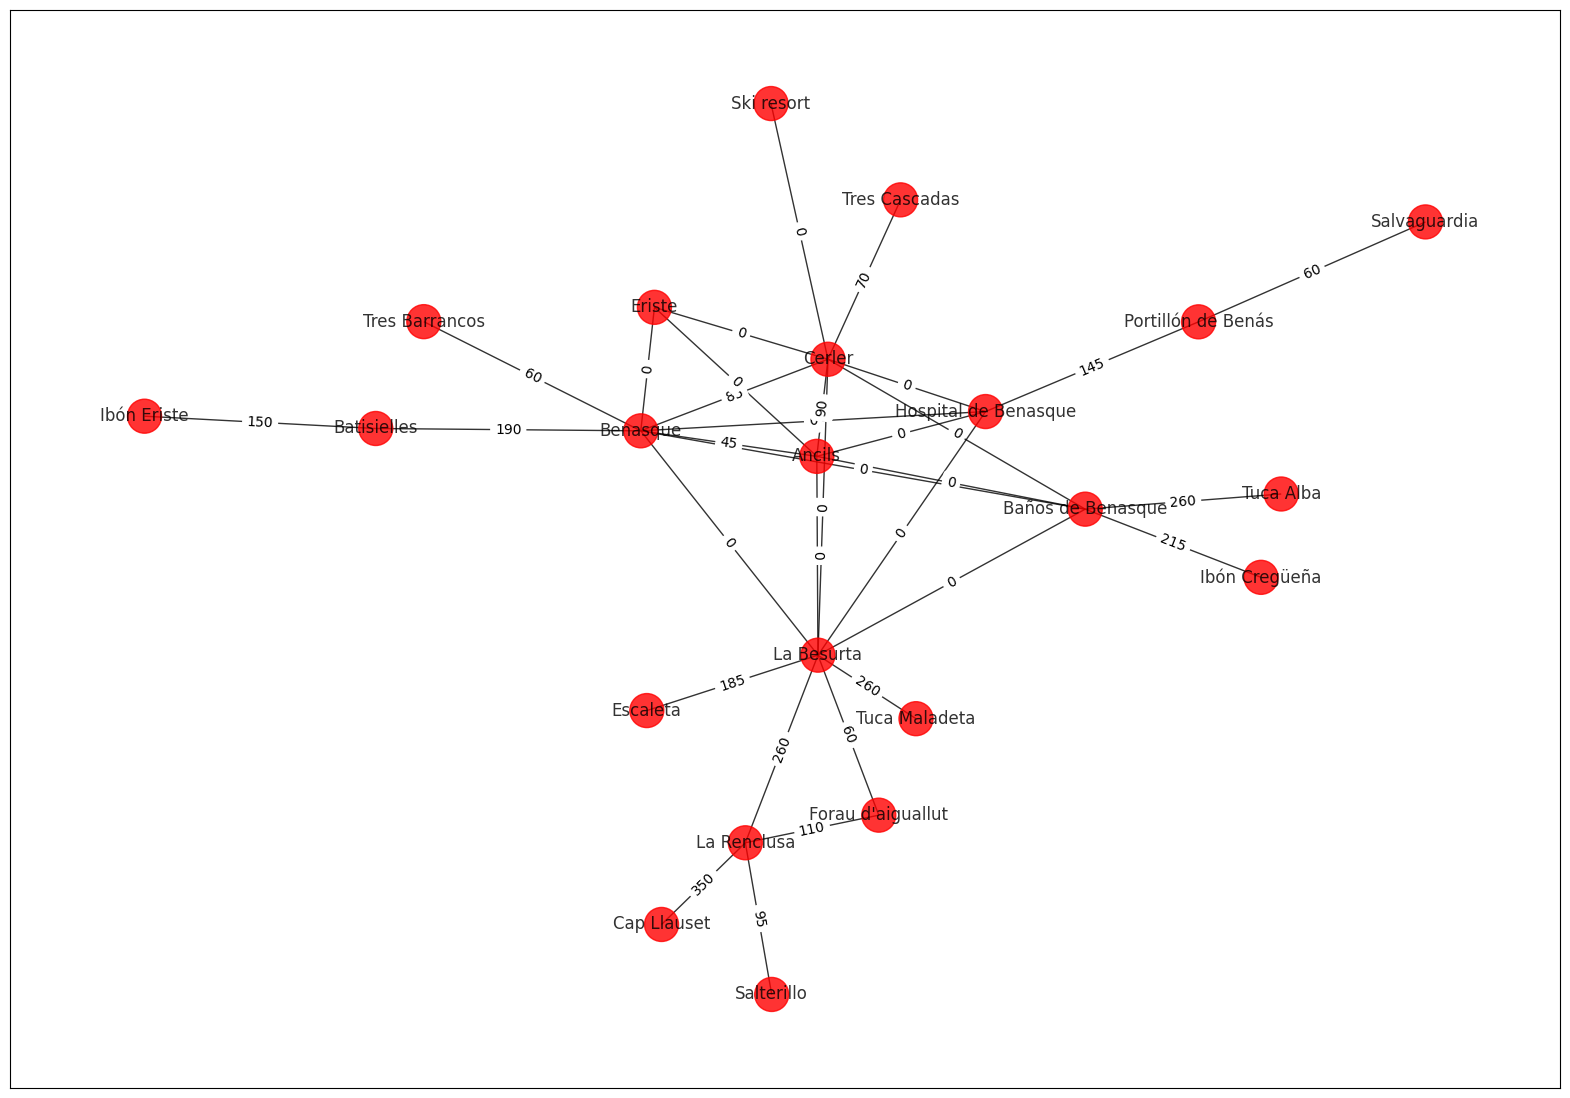

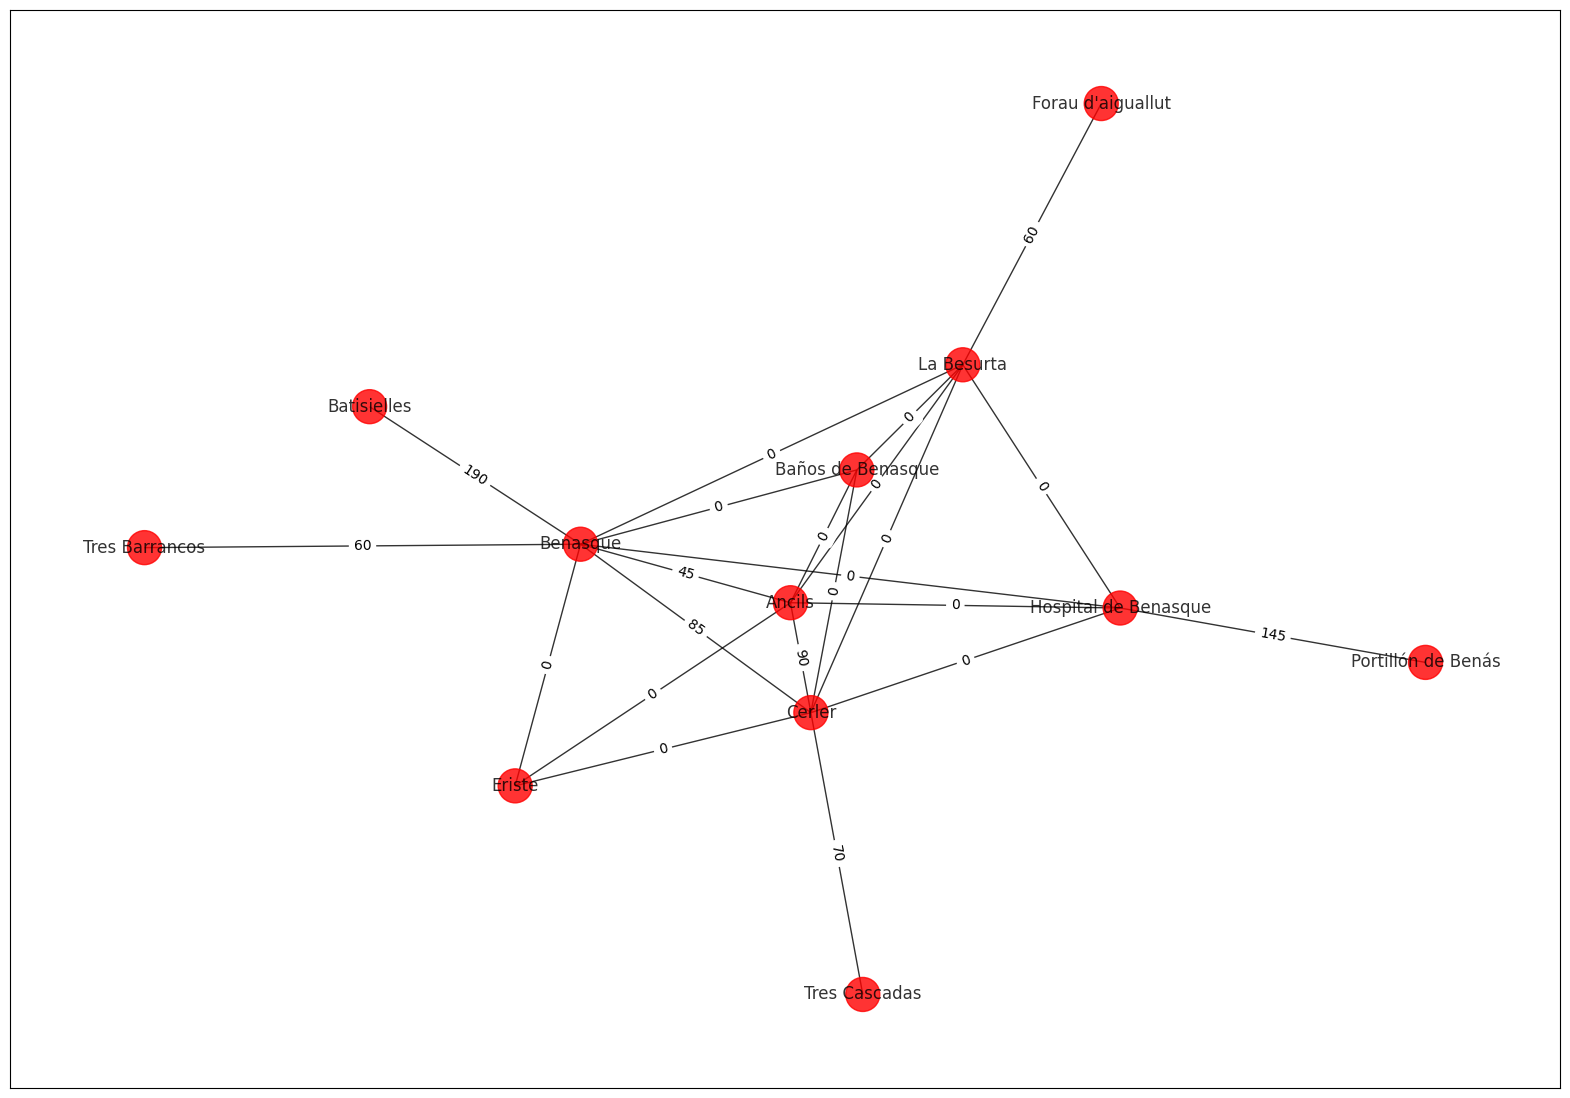

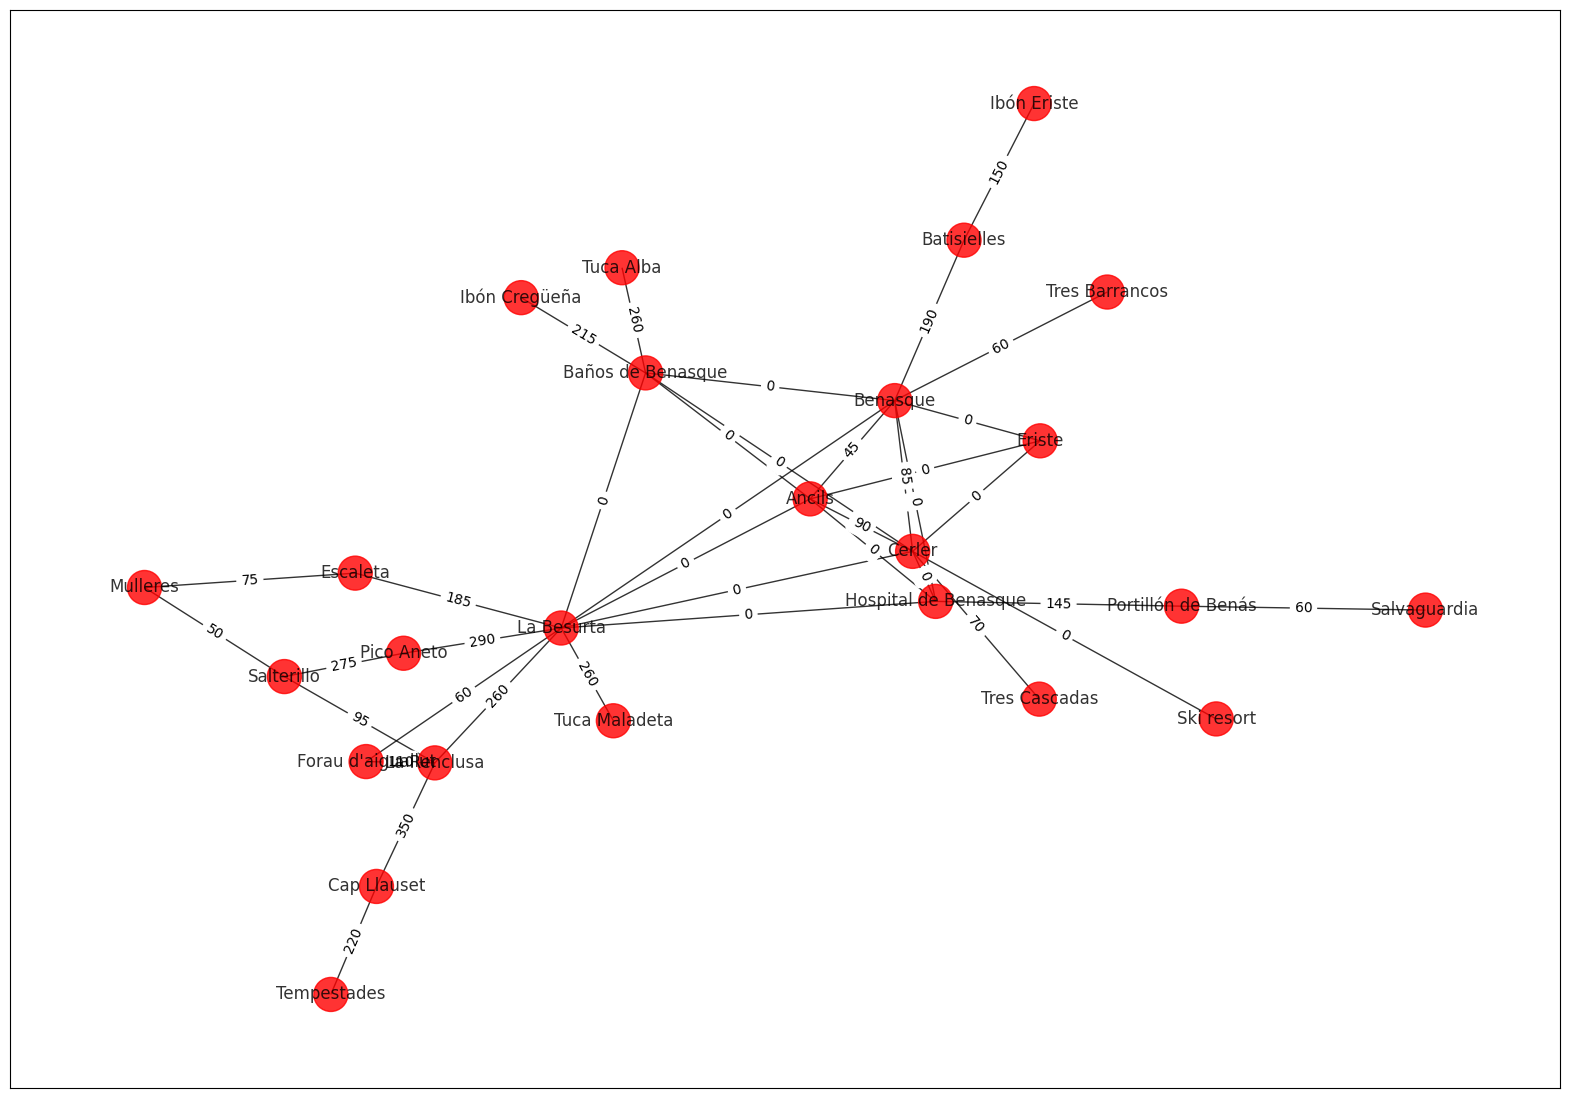

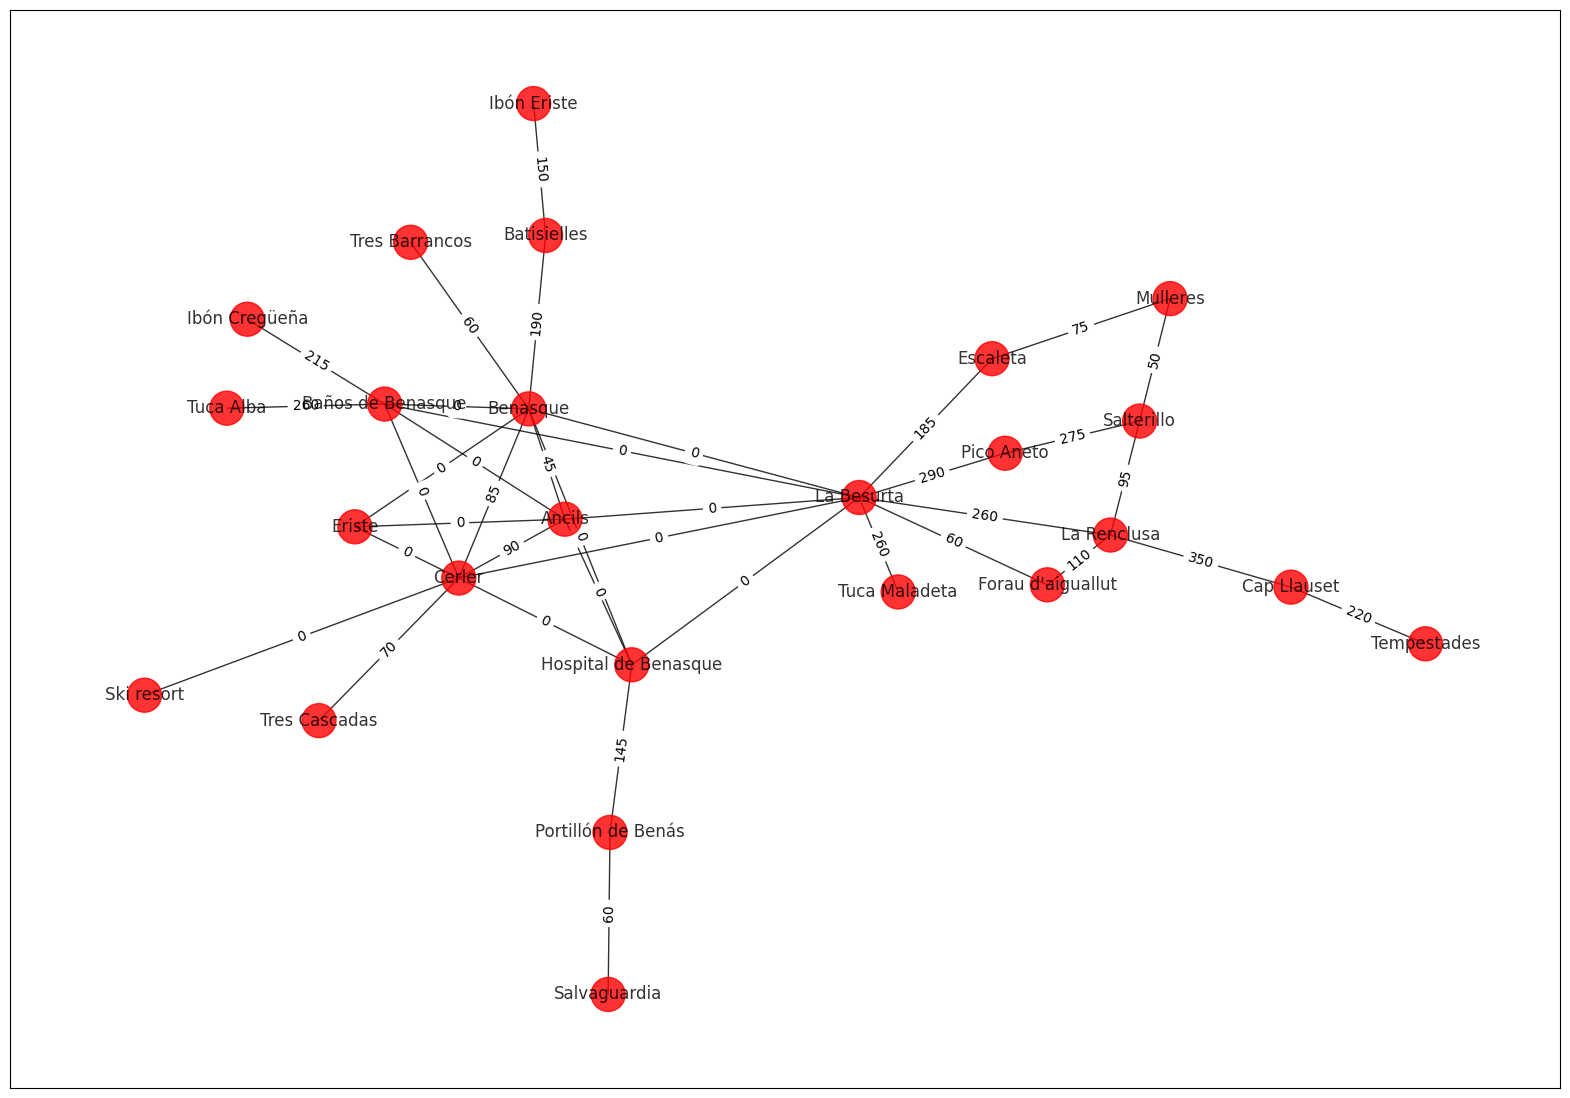

In [29]:
times = ["Summer", "Winter"]
max_gears = ["Urban", "Trail", "Mountain", "Snow"]

for gear in max_gears:
    for time in times:
        print(time, max_gears)


        draw_benasque_graph(limited_conditions(adjacency_dict, max_gear=gear, time=time))

Benasque
Cerler
Ancils
Baños de Benasque
Hospital de Benasque
Eriste
[[-1. 85. 45.  0.  0.  0.]
 [85. -1. 90.  0.  0.  0.]
 [45. 90. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1. -1.]
 [ 0.  0.  0. -1. -1. -1.]
 [ 0.  0.  0. -1. -1. -1.]]



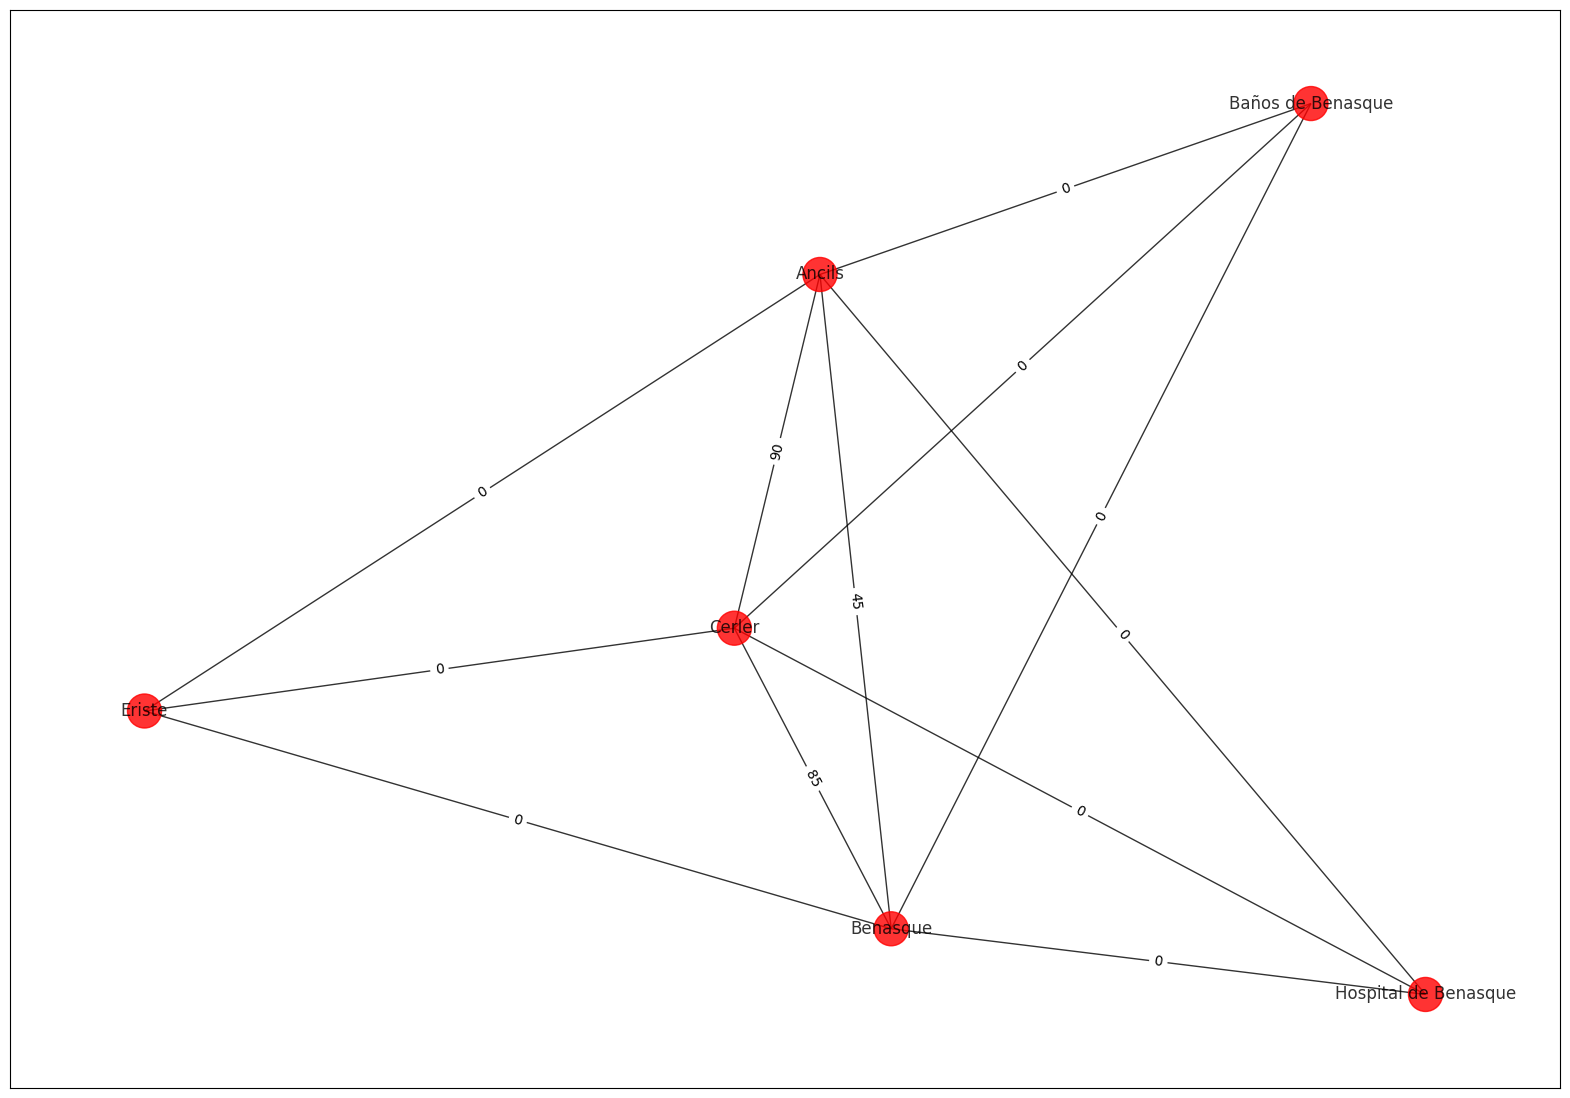

In [34]:
filtered_adjacency = limited_conditions(adjacency_dict, max_gear="Urban", time="Summer")

def reindex_dict(adjacency_dict):
    relabeling = {v: i+1 for i, v in enumerate(adjacency_dict)}
    return {relabeling[old]: {relabeling[oldn]: weight for oldn, weight in neighbours.items()} for old, neighbours in adjacency_dict.items()}

for i in filtered_adjacency:
    print(index_to_place[i])

print(generate_adjacency_matrix(reindex_dict(filtered_adjacency)))
draw_benasque_graph(filtered_adjacency)